In [2]:
!pip install -q gradio opencv-python pillow

In [3]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2

from PIL import Image

import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/CV-ccp/Saved_Model/Scene_Classification_MobileNetV2.keras"

model = load_model(MODEL_PATH)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [6]:
class_names = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [7]:
def predict_scene(image):

    # PIL Image -> NumPy
    image = np.array(image).astype(np.uint8)

    # Original image save
    original = image.copy()

    # Resize
    img = cv2.resize(image, (224,224))

    # Preprocess
    img = preprocess_input(img.astype(np.float32))

    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)[0]

    # Predicted Class
    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = float(np.max(prediction) * 100)

    # Probability Dictionary
    probabilities = {}

    for i in range(len(class_names)):
        probabilities[class_names[i]] = float(prediction[i])

    return original, predicted_class, confidence, probabilities

Saving pan3.JPG to pan3 (1).JPG
Prediction : street
Confidence : 99.44%

Class Probabilities

buildings    : 0.55%
forest       : 0.00%
glacier      : 0.01%
mountain     : 0.00%
sea          : 0.00%
street       : 99.44%


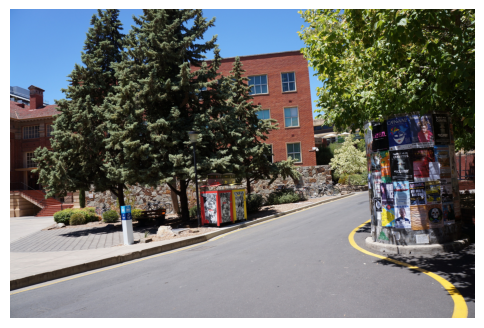

In [10]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

img = Image.open(image_name).convert("RGB")

original, pred, conf, probs = predict_scene(img)

print("="*50)
print("Prediction :", pred)
print(f"Confidence : {conf:.2f}%")
print("="*50)

print("\nClass Probabilities\n")

for k, v in probs.items():
    print(f"{k:12s} : {v*100:.2f}%")

plt.figure(figsize=(6,6))
plt.imshow(original)
plt.axis("off")
plt.show()

In [11]:
def gradio_predict(image):

    original, pred, conf, probs = predict_scene(image)

    prob_text = ""

    for k, v in probs.items():
        prob_text += f"{k:<12} : {v*100:.2f}%\n"

    return (
        original,
        pred,
        f"{conf:.2f} %",
        prob_text
    )

In [12]:
with gr.Blocks(theme=gr.themes.Soft(), title="Scene Classification") as demo:

    gr.Markdown(
    """
    # 🌍 Scene Classification using MobileNetV2

    Upload any outdoor image and click **Predict Scene**.
    """
    )

    with gr.Row():

        input_image = gr.Image(
            type="pil",
            label="Upload Image"
        )

        output_image = gr.Image(
            label="Preview"
        )

    predict_btn = gr.Button(
        "🔍 Predict Scene",
        variant="primary"
    )

    with gr.Row():

        prediction = gr.Textbox(
            label="Prediction"
        )

        confidence = gr.Textbox(
            label="Confidence"
        )

    probabilities = gr.Textbox(
        label="Class Probabilities",
        lines=8
    )

    predict_btn.click(
        fn=gradio_predict,
        inputs=input_image,
        outputs=[
            output_image,
            prediction,
            confidence,
            probabilities
        ]
    )

demo.launch(debug=True)

/tmp/ipykernel_7177/1335053493.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Scene Classification") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://aebbce070fb2205162.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://aebbce070fb2205162.gradio.live


In [13]:
import gradio as gr

css = """

body{
    background:#0f172a;
}

.gradio-container{
    max-width:1400px !important;
    margin:auto;
    background:#0f172a;
}

.main-title{

text-align:center;

font-size:42px;

font-weight:bold;

background:linear-gradient(90deg,#38bdf8,#818cf8,#ec4899);

-webkit-background-clip:text;

-webkit-text-fill-color:transparent;

margin-bottom:10px;

}

.subtitle{

text-align:center;

font-size:18px;

color:#cbd5e1;

margin-bottom:30px;

}

.card{

border-radius:20px;

background:#1e293b;

padding:20px;

box-shadow:0 0 20px rgba(0,0,0,.35);

}

"""

with gr.Blocks(css=css,title="AI Scene Classification") as demo:

    gr.HTML("""
    <div class='main-title'>
    🌍 AI Scene Classification System
    </div>

    <div class='subtitle'>
    MobileNetV2 • Deep Learning • Grad-CAM Visualization
    </div>
    """)

    with gr.Row():

        with gr.Column(scale=1):

            with gr.Group():

                input_image = gr.Image(
                    type="pil",
                    label="📷 Upload Image",
                    height=420
                )

                predict_btn = gr.Button(
                    "🧠 Predict Scene",
                    size="lg",
                    variant="primary"
                )

        with gr.Column(scale=1):

            preview = gr.Image(
                label="🖼 Image Preview",
                height=420
            )

    with gr.Row():

        prediction = gr.Textbox(
            label="🎯 Prediction",
            interactive=False
        )

        confidence = gr.Textbox(
            label="📈 Confidence",
            interactive=False
        )

    probabilities = gr.Textbox(
        label="📊 Class Probabilities",
        lines=8
    )

/tmp/ipykernel_7177/2198000968.py:59: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=css,title="AI Scene Classification") as demo:


# Premium Ui

In [14]:
import gradio as gr

# ---------------------------------------------------
# Professional CSS
# ---------------------------------------------------

css = """

body{
background:#0f172a;
}

.gradio-container{

max-width:1500px !important;

margin:auto;

background:#0f172a;

}

footer{
visibility:hidden;
}

#title{

font-size:48px;

font-weight:900;

text-align:center;

margin-top:15px;

margin-bottom:8px;

background:linear-gradient(
90deg,
#00d4ff,
#6366f1,
#ec4899
);

-webkit-background-clip:text;

-webkit-text-fill-color:transparent;

}

#subtitle{

text-align:center;

font-size:18px;

color:#cbd5e1;

margin-bottom:25px;

}

.card{

background:#1e293b;

padding:20px;

border-radius:20px;

box-shadow:0px 0px 18px rgba(0,0,0,.45);

}

"""

# ---------------------------------------------------
# Dashboard Layout
# ---------------------------------------------------

with gr.Blocks(

theme=gr.themes.Soft(),

css=css,

title="AI Scene Classification"

) as demo:

    gr.HTML("""

    <div id='title'>

    🌍 AI Scene Classification System

    </div>

    <div id='subtitle'>

    MobileNetV2 • Deep Learning • Grad-CAM

    </div>

    """)

    with gr.Row():

        with gr.Column(scale=1):

            input_image = gr.Image(

                type="pil",

                label="📷 Upload Image",

                height=430

            )

            predict_btn = gr.Button(

                "🧠 Analyze Scene",

                variant="primary",

                size="lg"

            )

        with gr.Column(scale=1):

            preview = gr.Image(

                label="🖼 Image Preview",

                height=430

            )

    gr.Markdown("---")

    prediction_card = gr.HTML()

    probability_card = gr.HTML()

/tmp/ipykernel_7177/2440182145.py:82: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


In [17]:
import gradio as gr

theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="violet",
    neutral_hue="slate",
).set(
    body_background_fill="#0F172A",
    body_text_color="white",
    block_background_fill="#1E293B",
    block_border_width="0px",
    button_primary_background_fill="#2563EB",
    button_primary_background_fill_hover="#1D4ED8",
    button_primary_text_color="white"
)

In [25]:
import gradio as gr

theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="violet",
    neutral_hue="slate",
).set(
    body_background_fill="#0F172A",
    body_text_color="white",
    block_background_fill="#1E293B",
    block_border_width="0px",
    button_primary_background_fill="#2563EB",
    button_primary_background_fill_hover="#1D4ED8",
    button_primary_text_color="white"
)


with gr.Blocks(theme=theme,title="AI Scene Classification") as demo:

    gr.Markdown("""
    # 🌍 AI Scene Classification Dashboard

    ### MobileNetV2 | Deep Learning | Grad-CAM
    """)

    with gr.Row():

        with gr.Column(scale=1):

            input_image = gr.Image(
                type="pil",
                label="📤 Upload Image",
                height=450
            )

            predict_btn = gr.Button(
                "🚀 Analyze Scene",
                variant="primary",
                size="lg"
            )

        with gr.Column(scale=1):

            preview = gr.Image(
                label="🖼 Preview",
                height=450
            )

    with gr.Row():

        prediction = gr.Label(
            label="Prediction",
            num_top_classes=6
        )

    gradcam = gr.Image(
        label="🔥 Grad-CAM Visualization",
        height=450
    )





    def ui_predict(image):

        original,pred,conf,probs = predict_scene(image)

        return (
            original,
            probs,
            original
        )

    predict_btn.click(
        fn=ui_predict,
        inputs=input_image,
        outputs=[
            preview,
            prediction,
            gradcam
        ]
    )

    demo.launch()

/tmp/ipykernel_7177/282643244.py:18: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme,title="AI Scene Classification") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a2c8bd654eee7c6832.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
